# Multi-Disease Lung Pathology Detection from Chest X-Rays
## Using Deep Learning and Explainable AI
### Notebook 3C — Transfer Learning with VGG16

**Dataset:** CheXpert v1.0-small — Stanford University ML Group  
**Backbone:** VGG16 — Simonyan & Zisserman (2015). *Very Deep Convolutional Networks.* ICLR. https://arxiv.org/abs/1409.1556

> All training hyperparameters are **identical** across NB03A, NB03B, and NB03C. VGG16's purely sequential architecture (no skip connections, no dense reuse) makes it the key architectural baseline in this comparison.

| Phase | Config | Duration |
|-------|--------|----------|
| 1 — Feature extraction | Backbone frozen, lr=1e-3 | 10 epochs |
| 2 — Fine-tuning | Block4+Block5 unfrozen, lr=1e-5 | up to 20 epochs |

---

---
## 1. Environment Setup

In [1]:
import os, warnings, random, json, time, math
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, CSVLogger, LearningRateScheduler
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4

print('TensorFlow:', tf.__version__)
print('GPU       :', tf.config.list_physical_devices('GPU'))

2026-05-18 13:26:34.619180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779110794.864702      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779110794.929035      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779110795.473205      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779110795.473240      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779110795.473243      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


---
## 2. Configuration

All hyperparameters are **identical** across NB03A, NB03B, and NB03C. The only variable that differs is the CNN backbone architecture.

In [2]:
# ─── Paths (Kaggle) ──────────────────────────────────────────────────────────
BASE_PATH  = '/kaggle/input/datasets/ashery/chexpert'
OUT_DIR    = '/kaggle/working'
MODEL_NAME = 'vgg16'

# ─── Image & batch ────────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32

# ─── Dataset split sizes ──────────────────────────────────────────────────────
TRAIN_SIZE = 50000
VAL_SIZE   = 5000
TEST_SIZE  = 5000

# ─── Training hyperparameters — identical across NB03A, NB03B, NB03C ─────────
EPOCHS_P1        = 10
EPOCHS_P2        = 20
LR_P1            = 1e-3
LR_P2            = 1e-5
ES_PATIENCE      = 8
LABEL_SMOOTH_EPS = 0.05
FREEZE_THROUGH    = 'block3_pool'  # freeze everything up to and including block3

# ─── Labels ───────────────────────────────────────────────────────────────────
LABEL_COLS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]
NUM_CLASSES = len(LABEL_COLS)

print('Model      :', MODEL_NAME)
print('Unfreeze   : block4 + block5 (VGG16 high-level conv layers)')
print('Train size :', TRAIN_SIZE)

Model      : vgg16
Unfreeze   : block4 + block5 (VGG16 high-level conv layers)
Train size : 50000


---
## 3. Load & Prepare Data

**U-Mixed uncertainty strategy:** U-Ones for Edema, Atelectasis, Pleural Effusion, and Cardiomegaly — maximises sensitivity for high-cost missed detections. U-Zeros for all remaining labels.

In [3]:
train_raw = pd.read_csv(os.path.join(BASE_PATH, 'train.csv'))
valid_raw = pd.read_csv(os.path.join(BASE_PATH, 'valid.csv'))

# Frontal views only
train_frontal = train_raw[train_raw['Frontal/Lateral'] == 'Frontal'].copy()

# U-Mixed uncertainty strategy
# U-Ones for clinically critical labels, U-Zeros for the rest
U_ONES = ['Edema', 'Atelectasis', 'Pleural Effusion', 'Cardiomegaly']
for col in LABEL_COLS:
    fill = 1.0 if col in U_ONES else 0.0
    train_frontal[col] = train_frontal[col].fillna(0.0).replace(-1.0, fill).astype(np.float32)
    valid_raw[col]     = valid_raw[col].fillna(0.0).replace(-1.0, fill).astype(np.float32)

# Build full paths
def add_path(df):
    df = df.copy()
    df['full_path'] = df['Path'].str.replace(
        'CheXpert-v1.0-small/', '', regex=False
    ).apply(lambda p: os.path.join(BASE_PATH, p))
    return df

train_frontal = add_path(train_frontal)
gold_df       = add_path(valid_raw)

# Stratified 80/10/10 split — identical across NB03A, NB03B, NB03C
tr_all, tmp = train_test_split(
    train_frontal, test_size=0.20, random_state=SEED,
    stratify=train_frontal['Pleural Effusion']
)
val_all, te_all = train_test_split(
    tmp, test_size=0.50, random_state=SEED,
    stratify=tmp['Pleural Effusion']
)

train_df = tr_all.sample(n=min(TRAIN_SIZE, len(tr_all)), random_state=SEED).reset_index(drop=True)
val_df   = val_all.sample(n=min(VAL_SIZE,  len(val_all)),  random_state=SEED).reset_index(drop=True)
test_df  = te_all.sample(n=min(TEST_SIZE,  len(te_all)),   random_state=SEED).reset_index(drop=True)

# Class weights for imbalanced labels
N = len(train_df)
pos_weights = np.array(
    [(N - train_df[c].sum()) / max(train_df[c].sum(), 1) for c in LABEL_COLS],
    dtype=np.float32
)

print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df), '| Gold:', len(gold_df))
print('Sample path exists:', os.path.exists(train_df['full_path'].iloc[0]))

Train: 50000 | Val: 5000 | Test: 5000 | Gold: 234
Sample path exists: True


---
## 4. tf.data Pipeline

4-operation augmentation pipeline: RandomFlip, RandomRotation, RandomZoom, RandomContrast. `RandomBrightness` excluded — causes GPU sync overhead. Pipeline is identical across NB03A, NB03B, NB03C.

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

# Augmentation: 4 ops — fast, no RandomBrightness which causes slow GPU sync
augment_layer = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom((-0.08, 0.08)),
    layers.RandomContrast(0.10),
], name='augmentation')


def load_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.repeat(img, 3, axis=-1)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def augment_fn(img, label):
    img = augment_layer(tf.expand_dims(img, 0), training=True)[0]
    return tf.clip_by_value(img, 0.0, 1.0), label


def make_ds(df, augment=False, shuffle=False):
    paths  = df['full_path'].values
    labels = df[LABEL_COLS].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(8000, seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_ds(train_df, augment=True,  shuffle=True)
val_ds   = make_ds(val_df,   augment=False, shuffle=False)
test_ds  = make_ds(test_df,  augment=False, shuffle=False)
gold_ds  = make_ds(gold_df,  augment=False, shuffle=False)

print('train_ds:', len(train_df), '->', len(train_df)//BATCH_SIZE, 'batches/epoch')
print('val_ds  :', len(val_df))
print('test_ds :', len(test_df))
print('gold_ds :', len(gold_df))

I0000 00:00:1779110823.244985      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779110823.251211      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


train_ds: 50000 -> 1562 batches/epoch
val_ds  : 5000
test_ds : 5000
gold_ds : 234


---
## 5. Model Architecture — VGG16

VGG16 (Simonyan & Zisserman, 2015) uses uniform 3×3 convolutional filters in 5 blocks — no skip connections, no dense reuse. Its simplicity is its defining characteristic and the reason it serves as the architectural baseline. 16 weight layers, ~138M parameters, pre-trained on ImageNet. GlobalAveragePooling2D replaces VGG16's original Flatten+FC layers, reducing head parameters from ~102M to ~400K.

```
VGG16 base (ImageNet, frozen in Phase 1)
  └─ GlobalAveragePooling2D
      └─ Dense(512, relu) + BatchNorm + Dropout(0.5)
          └─ Dense(256, relu) + BatchNorm + Dropout(0.3)
              └─ Dense(14, sigmoid)   ← 14 pathologies
```

> Head architecture is **identical** across NB03A, NB03B, NB03C.

In [5]:
def build_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input')
    base = VGG16(
        include_top=False, weights='imagenet',
        input_tensor=inputs, pooling=None
    )
    base.trainable = False

    x = layers.GlobalAveragePooling2D(name='gap')(base.output)
    x = layers.Dense(512, name='fc1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(0.5, name='drop1')(x)
    x = layers.Dense(256, name='fc2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    out = layers.Dense(NUM_CLASSES, activation='sigmoid', name='predictions')(x)
    return Model(inputs, out, name='VGG16_CheXpert'), base

model, base_model = build_model()
tr = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
nt = sum(int(np.prod(v.shape)) for v in model.non_trainable_variables)
print('Total params   :', model.count_params())
print('Trainable P1   :', tr, '(head only)')
print('Non-trainable  :', nt, '(frozen backbone)')
print('Backbone layers:', len(base_model.layers))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params   : 15115342
Trainable P1   : 399118 (head only)
Non-trainable  : 14716228 (frozen backbone)
Backbone layers: 19


---
## 6. Loss Function — Weighted BCE with Label Smoothing

Combines class-weighted binary cross-entropy (corrects label imbalance) with label smoothing ε=0.05 (Szegedy et al., 2016). Identical across all notebooks.

In [6]:
def build_loss(pos_weights, eps=LABEL_SMOOTH_EPS):
    pw  = tf.constant(pos_weights, dtype=tf.float32)
    eps = tf.constant(eps, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        ys = y_true * (1.0 - eps) + 0.5 * eps
        yp = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        return tf.reduce_mean(
            -(pw * ys * tf.math.log(yp) + (1.0 - ys) * tf.math.log(1.0 - yp))
        )
    return loss_fn

loss_fn = build_loss(pos_weights)
print('Loss ready. Label smoothing eps =', LABEL_SMOOTH_EPS)

Loss ready. Label smoothing eps = 0.05


---
## 7. Callbacks

ModelCheckpoint saves best `val_auc`. EarlyStopping patience=8 prevents premature stopping. Phase 2 adds cosine LR annealing (Loshchilov & Hutter, 2017).

In [7]:
CKPT = os.path.join(OUT_DIR, MODEL_NAME + '_best.h5')


def cosine_lr(epoch, lr):
    cos = 0.5 * (1.0 + math.cos(math.pi * epoch / max(EPOCHS_P2 - 1, 1)))
    return float(1e-8 + (LR_P2 - 1e-8) * cos)


def get_callbacks(phase):
    cbs = [
        ModelCheckpoint(CKPT, monitor='val_auc', mode='max',
                        save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_auc', mode='max',
                      patience=ES_PATIENCE, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=3, min_lr=1e-8, verbose=1),
        CSVLogger(os.path.join(OUT_DIR, MODEL_NAME + '_p' + str(phase) + '.csv')),
    ]
    if phase == 2:
        cbs.append(LearningRateScheduler(cosine_lr, verbose=0))
    return cbs

print('Checkpoint:', CKPT)

Checkpoint: /kaggle/working/vgg16_best.h5


---
## 8. Phase 1 — Feature Extraction

Backbone fully frozen. Only the classification head is trained for 10 epochs. Expected: ~1s/step on Kaggle T4.

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(LR_P1), loss=loss_fn,
    metrics=[keras.metrics.AUC(multi_label=True, name='auc'),
             keras.metrics.BinaryAccuracy(name='acc', threshold=0.5)]
)

print('Phase 1 | backbone fully frozen | lr =', LR_P1)
print('Batches/epoch:', len(train_df) // BATCH_SIZE)
t0 = time.time()
h1 = model.fit(train_ds, validation_data=val_ds,
               epochs=EPOCHS_P1, callbacks=get_callbacks(1), verbose=1)
print('P1 done in', round((time.time()-t0)/60, 1), 'min')
print('Best val_auc P1:', round(max(h1.history['val_auc']), 4))

Phase 1 | backbone fully frozen | lr = 0.001
Batches/epoch: 1562
Epoch 1/10


I0000 00:00:1779110830.510353      70 service.cc:152] XLA service 0x7af254007320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779110830.510389      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779110830.510394      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779110831.471631      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779110847.065593      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 906ms/step - acc: 0.4225 - auc: 0.5958 - loss: 1.3649
Epoch 1: val_auc improved from -inf to 0.67003, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1529s 966ms/step - acc: 0.4225 - auc: 0.5959 - loss: 1.3649 - val_acc: 0.3986 - val_auc: 0.6700 - val_loss: 1.2610 - learning_rate: 0.0010
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - acc: 0.3993 - auc: 0.6498 - loss: 1.2633
Epoch 2: val_auc improved from 0.67003 to 0.68103, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 629s 402ms/step - acc: 0.3993 - auc: 0.6498 - loss: 1.2633 - val_acc: 0.3934 - val_auc: 0.6810 - val_loss: 1.2528 - learning_rate: 0.0010
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - acc: 0.4020 - auc: 0.6694 - loss: 1.2511
Epoch 3: val_auc improved from 0.68103 to 0.68761, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 595s 380ms/step - acc: 0.4020 - auc: 0.6694 - loss: 1.2511 - val_acc: 0.4316 - val_auc: 0.6876 - val_loss: 1.2507 - learning_rate: 0.0010
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - acc: 0.4052 - auc: 0.6767 - loss: 1.2462
Epoch 4: val_auc improved from 0.68761 to 0.69135, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 591s 378ms/step - acc: 0.4052 - auc: 0.6767 - loss: 1.2462 - val_acc: 0.4008 - val_auc: 0.6914 - val_loss: 1.2506 - learning_rate: 0.0010
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - acc: 0.4044 - auc: 0.6799 - loss: 1.2434
Epoch 5: val_auc did not improve from 0.69135
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 606s 387ms/step - acc: 0.4044 - auc: 0.6799 - loss: 1.2434 - val_acc: 0.4126 - val_auc: 0.6875 - val_loss: 1.2496 - learning_rate: 0.0010
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - acc: 0.4060 - auc: 0.6865 - loss: 1.2399
Epoch 6: val_auc did not improve from 0.69135
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 594s 380ms/step - acc: 0.4060 - auc: 0.6865 - loss: 1.2399 - val_acc: 0.4122 - val_auc: 0.6811 - val_loss: 1.2599 - learning_rate: 0.0010
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - acc: 0.4096 - auc: 0.6876 - loss: 1.2407
Epoch 7: val_auc improved from 0.69135 to 0.69591, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 581s 372ms/step - acc: 0.4096 - auc: 0.6876 - loss: 1.2407 - val_acc: 0.4049 - val_auc: 0.6959 - val_loss: 1.2473 - learning_rate: 0.0010
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - acc: 0.4106 - auc: 0.6899 - loss: 1.2376
Epoch 8: val_auc did not improve from 0.69591
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 602s 385ms/step - acc: 0.4106 - auc: 0.6899 - loss: 1.2376 - val_acc: 0.4265 - val_auc: 0.6922 - val_loss: 1.2490 - learning_rate: 0.0010
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - acc: 0.4109 - auc: 0.6929 - loss: 1.2402
Epoch 9: val_auc did not improve from 0.69591
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 597s 382ms/step - acc: 0.4109 - auc: 0.6929 - loss: 1.2402 - val_acc: 0.4329 - val_auc: 0.6898 - val_loss: 1.2639 - learning_rate: 0.0010
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - acc: 0.4126 - auc: 0.6962 - loss: 1.2360
Epoch 10: val_auc improved from 0.69591 to 0.69818, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 610s 390ms/step - acc: 0.4126 - auc: 0.6962 - loss: 1.2360 - val_acc: 0.3961 - val_auc: 0.6982 - val_loss: 1.2423 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.
P1 done in 115.6 min
Best val_auc P1: 0.6982


---
## 9. Phase 2 — Fine-Tuning

VGG16 block4 and block5 unfrozen — 512-filter layers encoding the highest-level visual features. Blocks 1–3 remain frozen to preserve low-level edge/texture features.

| VGG16 block | Filters | Phase 2 |
|-------------|---------|----------|
| Block1–3 | 64–256 | Frozen |
| Block4–5 | 512 | Unfrozen |

In [9]:
# Unfreeze block4 + block5 — high-level semantic features
base_model.trainable = True
freeze = True
for layer in base_model.layers:
    if layer.name == FREEZE_THROUGH:
        freeze = False
    layer.trainable = not freeze

n_frozen   = sum(1 for l in base_model.layers if not l.trainable)
n_unfrozen = sum(1 for l in base_model.layers if l.trainable)
print('Frozen:', n_frozen, '| Unfrozen:', n_unfrozen, '(block4 + block5)')

model.compile(
    optimizer=keras.optimizers.Adam(LR_P2), loss=loss_fn,
    metrics=[keras.metrics.AUC(multi_label=True, name='auc'),
             keras.metrics.BinaryAccuracy(name='acc', threshold=0.5)]
)

t0 = time.time()
h2 = model.fit(train_ds, validation_data=val_ds,
               epochs=EPOCHS_P2, callbacks=get_callbacks(2), verbose=1)
print('P2 done in', round((time.time()-t0)/60,1), 'min')
print('Best val_auc P2:', round(max(h2.history['val_auc']),4))

Frozen: 10 | Unfrozen: 9 (block4 + block5)
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - acc: 0.4208 - auc: 0.7074 - loss: 1.2286
Epoch 1: val_auc improved from -inf to 0.71787, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 786s 491ms/step - acc: 0.4208 - auc: 0.7074 - loss: 1.2286 - val_acc: 0.4353 - val_auc: 0.7179 - val_loss: 1.2294 - learning_rate: 1.0000e-05
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - acc: 0.4347 - auc: 0.7260 - loss: 1.2114
Epoch 2: val_auc improved from 0.71787 to 0.72673, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 742s 475ms/step - acc: 0.4347 - auc: 0.7260 - loss: 1.2114 - val_acc: 0.4480 - val_auc: 0.7267 - val_loss: 1.2221 - learning_rate: 9.9319e-06
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - acc: 0.4430 - auc: 0.7353 - loss: 1.2071
Epoch 3: val_auc improved from 0.72673 to 0.74052, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 736s 471ms/step - acc: 0.4430 - auc: 0.7353 - loss: 1.2071 - val_acc: 0.4374 - val_auc: 0.7405 - val_loss: 1.2115 - learning_rate: 9.7294e-06
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - acc: 0.4493 - auc: 0.7441 - loss: 1.1993
Epoch 4: val_auc improved from 0.74052 to 0.74163, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 750s 480ms/step - acc: 0.4493 - auc: 0.7441 - loss: 1.1993 - val_acc: 0.4533 - val_auc: 0.7416 - val_loss: 1.2097 - learning_rate: 9.3980e-06
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - acc: 0.4555 - auc: 0.7500 - loss: 1.1947
Epoch 5: val_auc improved from 0.74163 to 0.74547, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 733s 469ms/step - acc: 0.4555 - auc: 0.7501 - loss: 1.1947 - val_acc: 0.4561 - val_auc: 0.7455 - val_loss: 1.2064 - learning_rate: 8.9468e-06
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - acc: 0.4589 - auc: 0.7547 - loss: 1.1908
Epoch 6: val_auc improved from 0.74547 to 0.74955, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 740s 473ms/step - acc: 0.4589 - auc: 0.7547 - loss: 1.1908 - val_acc: 0.4721 - val_auc: 0.7496 - val_loss: 1.1978 - learning_rate: 8.3880e-06
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - acc: 0.4629 - auc: 0.7594 - loss: 1.1855
Epoch 7: val_auc improved from 0.74955 to 0.75002, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 735s 470ms/step - acc: 0.4629 - auc: 0.7594 - loss: 1.1855 - val_acc: 0.4401 - val_auc: 0.7500 - val_loss: 1.2026 - learning_rate: 7.7370e-06
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - acc: 0.4677 - auc: 0.7666 - loss: 1.1810
Epoch 8: val_auc improved from 0.75002 to 0.75332, saving model to /kaggle/working/vgg16_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 767s 491ms/step - acc: 0.4677 - auc: 0.7666 - loss: 1.1810 - val_acc: 0.4674 - val_auc: 0.7533 - val_loss: 1.2007 - learning_rate: 7.0115e-06
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - acc: 0.4708 - auc: 0.7713 - loss: 1.1772
Epoch 9: val_auc did not improve from 0.75332

Epoch 9: ReduceLROnPlateau reducing learning rate to 1.8693600395636166e-06.
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 746s 477ms/step - acc: 0.4708 - auc: 0.7713 - loss: 1.1772 - val_acc: 0.4531 - val_auc: 0.7446 - val_loss: 1.2154 - learning_rate: 1.8694e-06
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - acc: 0.4749 - auc: 0.7756 - loss: 1.1735
Epoch 10: val_auc did not improve from 0.75332
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 738s 472ms/step - acc: 0.4749 - auc: 0.7756 - loss: 1.1735 - val_acc: 0.4773 - val_auc: 0.7453 - val_loss: 1.2141 - learning_rate: 5.4175e-06
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - acc: 0.4764 - auc: 0.7791 - loss: 1.1692
Epoch 11: v

---
## 10. Training Curves

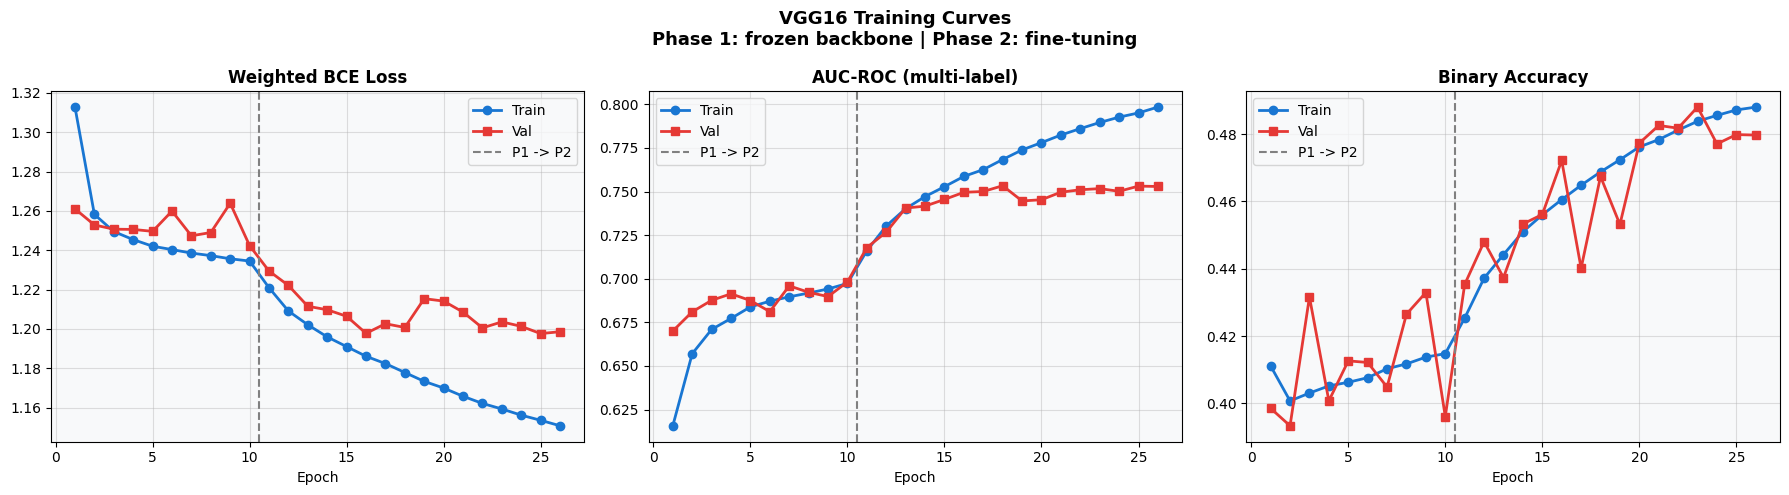

Saved: /kaggle/working/fig_vgg16_curves.png


In [10]:
def merge(h1, h2, k):
    return h1.history.get(k, []) + h2.history.get(k, [])

ep1 = len(h1.history['loss'])
tot = ep1 + len(h2.history['loss'])
x   = list(range(1, tot + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(MODEL_NAME.upper() + ' Training Curves\n'
             'Phase 1: frozen backbone | Phase 2: fine-tuning',
             fontsize=13, fontweight='bold')

for ax, (tk, vk, title) in zip(axes, [
    ('loss', 'val_loss', 'Weighted BCE Loss'),
    ('auc',  'val_auc',  'AUC-ROC (multi-label)'),
    ('acc',  'val_acc',  'Binary Accuracy')
]):
    ax.plot(x, merge(h1, h2, tk), 'o-', color='#1976D2', label='Train', lw=2)
    ax.plot(x, merge(h1, h2, vk), 's-', color='#E53935', label='Val',   lw=2)
    ax.axvline(ep1 + 0.5, color='gray', linestyle='--', lw=1.5, label='P1 -> P2')
    ax.set_xlabel('Epoch'); ax.set_title(title, fontweight='bold'); ax.legend()

plt.tight_layout()
out = os.path.join(OUT_DIR, 'fig_' + MODEL_NAME + '_curves.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show(); print('Saved:', out)

---
## 11. Evaluation — AUC-ROC Per Label

Best checkpoint weights loaded. AUC-ROC computed on test set (N=5,000) and gold set (N=234, radiologist-annotated).

In [11]:
model.load_weights(CKPT)
print('Best weights loaded from:', CKPT)


def predict(ds):
    yt, yp = [], []
    for imgs, labs in ds:
        yt.append(labs.numpy())
        yp.append(model(imgs, training=False).numpy())
    return np.vstack(yt), np.vstack(yp)


def calc_aucs(y_true, y_pred):
    r = {}
    for i, c in enumerate(LABEL_COLS):
        r[c] = float(roc_auc_score(y_true[:,i], y_pred[:,i])) \
               if int(y_true[:,i].sum()) >= 2 else float('nan')
    valid = [v for v in r.values() if not np.isnan(v)]
    r['MEAN_AUC'] = float(np.mean(valid))
    return r


print('Inference on test set...')
yt_test, yp_test = predict(test_ds)
print('Inference on gold set...')
yt_gold, yp_gold = predict(gold_ds)

auc_test = calc_aucs(yt_test, yp_test)
auc_gold = calc_aucs(yt_gold, yp_gold)

print()
print('Pathology'.ljust(35), 'Test AUC'.rjust(10), 'Gold AUC'.rjust(10))
print('-' * 60)
for col in LABEL_COLS:
    t = auc_test.get(col, float('nan'))
    g = auc_gold.get(col, float('nan'))
    print(col.ljust(35),
          ('-' if np.isnan(t) else str(round(t,4))).rjust(10),
          ('-' if np.isnan(g) else str(round(g,4))).rjust(10))
print('-' * 60)
print('MEAN AUC'.ljust(35),
      str(round(auc_test['MEAN_AUC'],4)).rjust(10),
      str(round(auc_gold['MEAN_AUC'],4)).rjust(10))

Best weights loaded from: /kaggle/working/vgg16_best.h5
Inference on test set...
Inference on gold set...

Pathology                             Test AUC   Gold AUC
------------------------------------------------------------
No Finding                              0.8795     0.7799
Enlarged Cardiomediastinum              0.6417     0.4498
Cardiomegaly                            0.8143     0.7752
Lung Opacity                            0.6962     0.8591
Lung Lesion                             0.7279          -
Edema                                   0.8069     0.8735
Consolidation                            0.706     0.8602
Pneumonia                               0.7014     0.6294
Atelectasis                             0.6692     0.7881
Pneumothorax                            0.8152     0.6847
Pleural Effusion                        0.8195     0.8709
Pleural Other                           0.6945          -
Fracture                                0.7384          -
Support Devices     

---
## 12. Per-Label AUC Visualisation

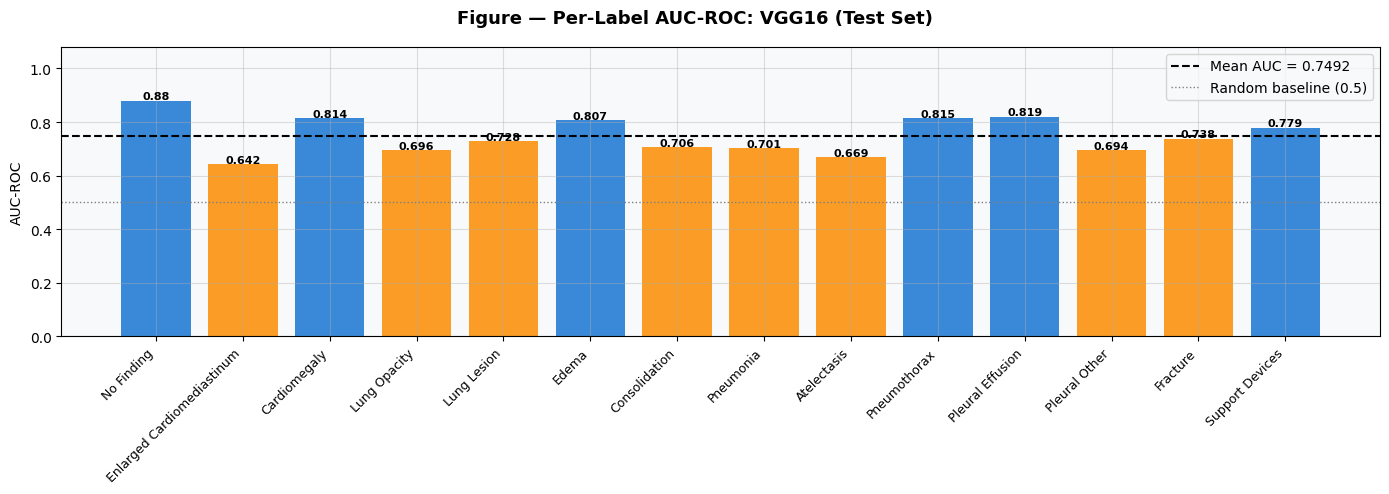

Saved: /kaggle/working/fig_vgg16_auc.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
vals   = [auc_test.get(c, 0.0) for c in LABEL_COLS]
colors = ['#1976D2' if v >= 0.75 else '#FB8C00' if v >= 0.60 else '#E53935'
          for v in vals]
bars = ax.bar(LABEL_COLS, vals, color=colors, alpha=0.85)
ax.axhline(auc_test['MEAN_AUC'], color='black', lw=1.5, linestyle='--',
           label='Mean AUC = ' + str(round(auc_test['MEAN_AUC'], 4)))
ax.axhline(0.5, color='gray', lw=1, linestyle=':', label='Random baseline (0.5)')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            str(round(v,3)), ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(LABEL_COLS)))
ax.set_xticklabels(LABEL_COLS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('AUC-ROC'); ax.set_ylim(0, 1.08); ax.legend(fontsize=10)
fig.suptitle('Figure — Per-Label AUC-ROC: ' + MODEL_NAME.upper() + ' (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = os.path.join(OUT_DIR, 'fig_' + MODEL_NAME + '_auc.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show(); print('Saved:', out)

---
## 13. Save Results

In [13]:
results = {
    'model': MODEL_NAME,
    'auc_test': {},
    'auc_gold': {},
    'config': {
        'epochs_p1': EPOCHS_P1, 'epochs_p2': EPOCHS_P2,
        'lr_p1': LR_P1, 'lr_p2': LR_P2,
        'es_patience': ES_PATIENCE,
        'label_smooth': LABEL_SMOOTH_EPS,
        'uncertainty': 'U-Mixed',
        'train_n': len(train_df), 'batch': BATCH_SIZE
    }
}

for col in LABEL_COLS + ['MEAN_AUC']:
    v = auc_test.get(col, float('nan'))
    results['auc_test'][col] = None if np.isnan(v) else round(v, 6)
    v = auc_gold.get(col, float('nan'))
    results['auc_gold'][col] = None if np.isnan(v) else round(v, 6)

out_j = os.path.join(OUT_DIR, MODEL_NAME + '_results.json')
with open(out_j, 'w') as f:
    json.dump(results, f, indent=2)

np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ypred_test.npy'), yp_test)
np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ytrue_test.npy'), yt_test)
np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ypred_gold.npy'), yp_gold)
np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ytrue_gold.npy'), yt_gold)

print('Results saved to:', OUT_DIR)
for fname in sorted(os.listdir(OUT_DIR)):
    if MODEL_NAME in fname:
        kb = os.path.getsize(os.path.join(OUT_DIR, fname)) / 1024
        print(' ', fname, round(kb,1), 'KB')

Results saved to: /kaggle/working
  fig_vgg16_auc.png 113.9 KB
  fig_vgg16_curves.png 165.2 KB
  vgg16_best.h5 163691.4 KB
  vgg16_p1.csv 1.4 KB
  vgg16_p2.csv 2.2 KB
  vgg16_results.json 1.1 KB
  vgg16_ypred_gold.npy 12.9 KB
  vgg16_ypred_test.npy 273.6 KB
  vgg16_ytrue_gold.npy 12.9 KB
  vgg16_ytrue_test.npy 273.6 KB


---
## 14. Summary

In [14]:
print('=' * 62)
print('  NOTEBOOK 3C — VGG16 SUMMARY')
print('=' * 62)
print('  Architecture : VGG16')
print('  Key property : Sequential 3x3 conv — no skip connections')
print('  Head         : GAP -> Dense(512) -> Dense(256) -> Dense(14)')
print()
print('  Training [identical config to all NB03 notebooks]')
print('    P1 :', EPOCHS_P1, 'epochs | backbone frozen | lr =', LR_P1)
print('    P2 : up to', EPOCHS_P2, 'epochs | block4+block5 unfrozen | lr =', LR_P2)
print('    EarlyStopping patience :', ES_PATIENCE)
print('    Label smoothing eps    :', LABEL_SMOOTH_EPS)
print('    Uncertainty strategy   : U-Mixed')
print('    Train N                :', len(train_df))
print()
print('  Results')
print('    Mean AUC (Test) :', round(auc_test['MEAN_AUC'],4))
print('    Mean AUC (Gold) :', round(auc_gold['MEAN_AUC'],4))
best = max([c for c in LABEL_COLS if not np.isnan(auc_test.get(c,float('nan')))],
           key=lambda c: auc_test[c])
print('    Best label      :', best, '=', round(auc_test[best],4))
print('=' * 62)

  NOTEBOOK 3C — VGG16 SUMMARY
  Architecture : VGG16
  Key property : Sequential 3x3 conv — no skip connections
  Head         : GAP -> Dense(512) -> Dense(256) -> Dense(14)

  Training [identical config to all NB03 notebooks]
    P1 : 10 epochs | backbone frozen | lr = 0.001
    P2 : up to 20 epochs | block4+block5 unfrozen | lr = 1e-05
    EarlyStopping patience : 8
    Label smoothing eps    : 0.05
    Uncertainty strategy   : U-Mixed
    Train N                : 50000

  Results
    Mean AUC (Test) : 0.7492
    Mean AUC (Gold) : 0.754
    Best label      : No Finding = 0.8795


---

## References

1. Simonyan, K., & Zisserman, A. (2015). **Very Deep Convolutional Networks for Large-Scale Image Recognition.** *ICLR.* https://arxiv.org/abs/1409.1556

2. Irvin, J., et al. (2019). **CheXpert.** *AAAI*, 33(01), 590–597.

3. He, K., et al. (2016). **Deep Residual Learning.** *CVPR*, 770–778.

4. Szegedy, C., et al. (2016). **Label Smoothing.** *CVPR*, 2818–2826.

5. Loshchilov, I., & Hutter, F. (2017). **Cosine Annealing.** *ICLR.*